In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from tabulate import tabulate
import matplotlib.pyplot as plt
from astropy.io import fits
from astroquery.sdss import SDSS

# STATISTICAL TESTS

In [2]:
def run_gaussianity_tests(data, dataset_name):
    """Performs 4 Gaussianity tests and returns a results table."""
    # Clean Data: Remove NaNs and Infs
    data = data[np.isfinite(data)]
    
    # 1. Kolmogorov-Smirnov
    mean, std = np.mean(data), np.std(data)
    ks_stat, ks_p = stats.kstest(data, 'norm', args=(mean, std))

    # 2. Shapiro-Wilk (limit to 5000 samples for performance/compatibility)
    sw_data = data[:5000] if len(data) > 5000 else data
    sw_stat, sw_p = stats.shapiro(sw_data)

    # 3. Pearson Chi-Square (D'Agostino's K^2)
    pc_stat, pc_p = stats.normaltest(data)

    # 4. Anderson-Darling
    ad_result = stats.anderson(data, dist='norm')
    ad_stat = ad_result.statistic
    ad_crit = ad_result.critical_values[2] # 5% significance level
    ad_verdict = "Pass (Gaussian)" if ad_stat < ad_crit else "Fail (Non-Gaussian)"

    # Prepare Table
    results = [
        ["K-S Test", f"{ks_stat:.4f}", f"{ks_p:.4f}", "Gaussian" if ks_p > 0.05 else "Non-Gaussian"],
        ["Shapiro-Wilk", f"{sw_stat:.4f}", f"{sw_p:.4f}", "Gaussian" if sw_p > 0.05 else "Non-Gaussian"],
        ["Pearson Chi-sq", f"{pc_stat:.4f}", f"{pc_p:.4f}", "Gaussian" if pc_p > 0.05 else "Non-Gaussian"],
        ["Anderson-Darling", f"{ad_stat:.4f}", f"Crit={ad_crit}", ad_verdict]
    ]

    print(f"\n{dataset_name} Gaussianity Test Results:")
    print(tabulate(results, headers=["Test", "Statistic", "p-value / Info", "Result (α=0.05)"], tablefmt="grid"))
    
    # Plotting
    plt.figure(figsize=(8, 4))
    plt.hist(data, bins=50, density=True, alpha=0.6, color='seagreen', edgecolor='black', label='Data Histogram')
    x = np.linspace(min(data), max(data), 100)
    plt.plot(x, stats.norm.pdf(x, mean, std), 'r-', lw=2, label='Theoretical Gaussian')
    plt.title(f"Distribution Analysis: {dataset_name}")
    plt.legend()
    plt.show()

    

# DATA ACQUISITION FUNCTIONS

In [3]:
def get_cmb_data():
    """Gaussian Case: Fetches a LOW-RES actual Planck CMB map (faster)."""
    
    print("Streaming Low-Res CMB Data (Planck LFI)...")

    url = "https://irsa.ipac.caltech.edu/data/Planck/release_3/all-sky-maps/maps/LFI_SkyMap_030_1024_R3.00_full.fits"
    
    with fits.open(url, cache=True) as hdul:    # cache=True
        map_data = hdul[1].data['I_STOKES']
        clean_data = map_data[np.isfinite(map_data)]
        l = len(clean_data) # 12582912
        print(f"Fetched {l} valid CMB pixels.")
        clean_data = clean_data[l//2:l//2 + 3000] # taking a central slice of 3000 pixels for testing
        mean, std = np.mean(clean_data), np.std(clean_data)
        processed_data = (clean_data - mean) / std 
        return processed_data 
            


def get_sdss_redshifts():
    """Non-Gaussian: SDSS Galaxy Redshifts."""
    
    print("Fetching SDSS Redshifts...")
    l = 50000 # limit is 500000 
    query = f"SELECT TOP {l} z FROM SpecObj WHERE class = 'GALAXY' AND z > 0.01"
    res = SDSS.query_sql(query)
    return np.array(res['z'])



# MAIN EXECUTION

Streaming Low-Res CMB Data (Planck LFI)...
Fetched 12582912 valid CMB pixels.
Fetching SDSS Redshifts...

Planck CMB (Gaussian Case) Gaussianity Test Results:
+------------------+-------------+------------------+-------------------+
| Test             |   Statistic | p-value / Info   | Result (α=0.05)   |
+==================+=============+==================+===================+
| K-S Test         |      0.0094 | 0.9523           | Gaussian          |
+------------------+-------------+------------------+-------------------+
| Shapiro-Wilk     |      0.9996 | 0.8373           | Gaussian          |
+------------------+-------------+------------------+-------------------+
| Pearson Chi-sq   |      0.6636 | 0.7176           | Gaussian          |
+------------------+-------------+------------------+-------------------+
| Anderson-Darling |      0.2211 | Crit=0.786       | Pass (Gaussian)   |
+------------------+-------------+------------------+-------------------+


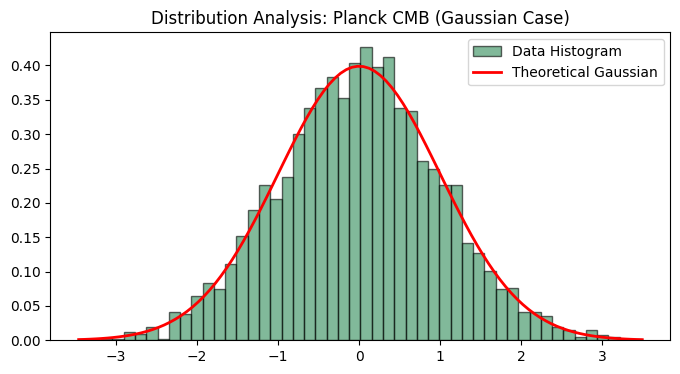


SDSS Redshifts (Non-Gaussian Case) Gaussianity Test Results:
+------------------+-------------+------------------+---------------------+
| Test             |   Statistic | p-value / Info   | Result (α=0.05)     |
+==================+=============+==================+=====================+
| K-S Test         |      0.0743 | 0.0000           | Non-Gaussian        |
+------------------+-------------+------------------+---------------------+
| Shapiro-Wilk     |      0.9423 | 0.0000           | Non-Gaussian        |
+------------------+-------------+------------------+---------------------+
| Pearson Chi-sq   |   3584.95   | 0.0000           | Non-Gaussian        |
+------------------+-------------+------------------+---------------------+
| Anderson-Darling |    647.693  | Crit=0.787       | Fail (Non-Gaussian) |
+------------------+-------------+------------------+---------------------+


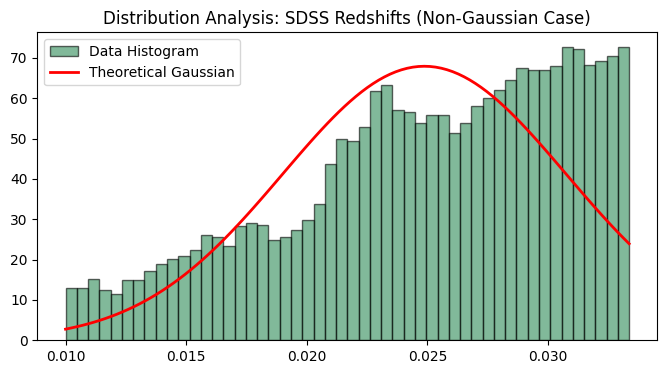

In [4]:
test_list = [
    (get_cmb_data(), "Planck CMB (Gaussian Case)"),
    (get_sdss_redshifts(), "SDSS Redshifts (Non-Gaussian Case)")
]

for data, name in test_list:
    run_gaussianity_tests(data, name) 